In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv


In [2]:
hotel_booking = pd.read_csv('/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv')

In [3]:
hotel_booking.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
hotel_booking.isna().sum() * 100 / len(hotel_booking)

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [5]:
hotel_booking[hotel_booking['agent'].isnull() & hotel_booking['company'].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
30,Resort Hotel,0,118,2015,July,27,1,4,10,1,...,No Deposit,NaN,NaN,0,Transient,62.0,0,2,Check-Out,2015-07-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119044,City Hotel,0,3,2017,August,34,26,1,1,2,...,No Deposit,NaN,NaN,0,Transient,124.0,0,1,Check-Out,2017-08-28
119046,City Hotel,0,0,2017,August,35,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,95.0,0,0,Check-Out,2017-08-28
119151,City Hotel,0,0,2017,August,35,29,0,1,2,...,No Deposit,NaN,NaN,0,Transient,270.0,0,0,Check-Out,2017-08-30
119166,City Hotel,0,0,2017,August,35,30,0,1,1,...,No Deposit,NaN,NaN,0,Transient,140.0,0,0,Check-Out,2017-08-31


In [6]:
hotel_booking['agent'].unique()
hotel_booking['agent'] = hotel_booking['agent'].fillna(-1)
hotel_booking.loc[(hotel_booking['agent'] == -1) & (hotel_booking['is_canceled'] == 0), ['agent', 'is_canceled', 'hotel']]
#hotel_booking.loc[(hotel_booking['agent']== -1)]
#hotel_booking.loc[(hotel_booking['is_canceled']== 0)]

,agent,is_canceled,hotel
0,-1.0,0,Resort Hotel
1,-1.0,0,Resort Hotel
2,-1.0,0,Resort Hotel
6,-1.0,0,Resort Hotel
18,-1.0,0,Resort Hotel
...,...,...,...
119124,-1.0,0,City Hotel
119151,-1.0,0,City Hotel
119166,-1.0,0,City Hotel
119215,-1.0,0,City Hotel


In [7]:
hotel_booking.dropna(subset = 'children', inplace = True)
hotel_booking.loc[hotel_booking['children'].isnull()]
#hotel_booking.loc[hotel_booking['country'].isnull()].describe()
#hotel_booking.drop(columns=['company'], inplace= True)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [8]:
hotel_booking.isna().sum() * 100 / len(hotel_booking)

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.000000
babies                             0.000000
meal                               0.000000
country                            0.408758
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [9]:
hotel_booking[hotel_booking['country'].isna()][['country', 'arrival_date_year', 'reservation_status_date', 'hotel']]

,country,arrival_date_year,reservation_status_date,hotel
30,NaN,2015,2015-07-15,Resort Hotel
4127,NaN,2016,2016-02-15,Resort Hotel
7092,NaN,2016,2016-07-20,Resort Hotel
7860,NaN,2016,2016-07-22,Resort Hotel
8779,NaN,2016,2016-10-13,Resort Hotel
...,...,...,...,...
65908,NaN,2017,2017-04-10,City Hotel
65909,NaN,2017,2017-04-10,City Hotel
65910,NaN,2017,2017-04-10,City Hotel
80830,NaN,2015,2015-11-26,City Hotel


In [10]:
hotel_booking.loc[hotel_booking['country'].isna(), 'country'] = 'Unknown'
hotel_booking.loc[hotel_booking['country'].isna()].sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                          0.0
babies                              0
meal                                0
country                             0
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
agent                             0.0
company                           0.0
days_in_waiting_list                0
customer_typ

In [11]:
hotel_booking.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [12]:
hotel_booking['children'].unique()
hotel_booking = hotel_booking.astype({'children': 'int', 'is_canceled': 'boolean', 'agent': 'int', 'is_repeated_guest': 'boolean'})
hotel_booking.dtypes

hotel                              object
is_canceled                       boolean
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                 boolean
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [13]:
len(hotel_booking)

119386

In [14]:
hotel_booking = hotel_booking.sort_values(by = 'arrival_date_year')

In [15]:
hotel_booking.head(60)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
17,Resort Hotel,False,12,2015,July,27,1,0,1,2,...,No Deposit,240,NaN,0,Transient,88.20,0,0,Check-Out,2015-07-02
16,Resort Hotel,False,37,2015,July,27,1,0,4,2,...,No Deposit,8,NaN,0,Contract,97.50,0,0,Check-Out,2015-07-05
15,Resort Hotel,False,68,2015,July,27,1,0,4,2,...,No Deposit,240,NaN,0,Transient,97.00,0,3,Check-Out,2015-07-05
14,Resort Hotel,False,37,2015,July,27,1,0,4,2,...,No Deposit,241,NaN,0,Transient,94.71,0,0,Check-Out,2015-07-05
13,Resort Hotel,False,18,2015,July,27,1,0,4,2,...,No Deposit,241,NaN,0,Transient,154.77,0,1,Check-Out,2015-07-05
12,Resort Hotel,False,68,2015,July,27,1,0,4,2,...,No Deposit,240,NaN,0,Transient,97.00,0,3,Check-Out,2015-07-05
11,Resort Hotel,False,35,2015,July,27,1,0,4,2,...,No Deposit,240,NaN,0,Transient,145.00,0,0,Check-Out,2015-07-05
10,Resort Hotel,True,23,2015,July,27,1,0,4,2,...,No Deposit,240,NaN,0,Transient,123.00,0,0,Canceled,2015-06-23
23167,Resort Hotel,False,277,2015,October,41,6,2,5,2,...,No Deposit,273,NaN,0,Transient-Party,68.74,0,0,Check-Out,2015-10-13
40073,City Hotel,False,4,2015,July,27,3,0,2,1,...,No Deposit,1,NaN,0,Transient-Party,63.00,0,0,Check-Out,2015-07-05


In [16]:
hotel_booking[hotel_booking['arrival_date_year'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [17]:
hotel_booking['lead_time'].describe()

count    119386.000000
mean        104.014801
std         106.863286
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

In [18]:
bins = [-1, 100, 200, 300, 400, 500, 600, 700, 800]
labels = ['-1-100', '101-200', '201-300', '301-400', '401-500', '501-600', '601-700', '701-800']

hotel_booking['lead_time_intervals'] = pd.cut(hotel_booking['lead_time'], bins = bins, labels=labels)

hotel_booking.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time_intervals
17,Resort Hotel,False,12,2015,July,27,1,0,1,2,...,240,NaN,0,Transient,88.20,0,0,Check-Out,2015-07-02,-1-100
16,Resort Hotel,False,37,2015,July,27,1,0,4,2,...,8,NaN,0,Contract,97.50,0,0,Check-Out,2015-07-05,-1-100
15,Resort Hotel,False,68,2015,July,27,1,0,4,2,...,240,NaN,0,Transient,97.00,0,3,Check-Out,2015-07-05,-1-100
14,Resort Hotel,False,37,2015,July,27,1,0,4,2,...,241,NaN,0,Transient,94.71,0,0,Check-Out,2015-07-05,-1-100
13,Resort Hotel,False,18,2015,July,27,1,0,4,2,...,241,NaN,0,Transient,154.77,0,1,Check-Out,2015-07-05,-1-100


In [19]:
hotel_booking[hotel_booking['lead_time_intervals'] == '101-200'].size

881529

In [20]:
hotel_booking.head(19)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time_intervals
17,Resort Hotel,False,12,2015,July,27,1,0,1,2,...,240,NaN,0,Transient,88.20,0,0,Check-Out,2015-07-02,-1-100
16,Resort Hotel,False,37,2015,July,27,1,0,4,2,...,8,NaN,0,Contract,97.50,0,0,Check-Out,2015-07-05,-1-100
15,Resort Hotel,False,68,2015,July,27,1,0,4,2,...,240,NaN,0,Transient,97.00,0,3,Check-Out,2015-07-05,-1-100
14,Resort Hotel,False,37,2015,July,27,1,0,4,2,...,241,NaN,0,Transient,94.71,0,0,Check-Out,2015-07-05,-1-100
13,Resort Hotel,False,18,2015,July,27,1,0,4,2,...,241,NaN,0,Transient,154.77,0,1,Check-Out,2015-07-05,-1-100
12,Resort Hotel,False,68,2015,July,27,1,0,4,2,...,240,NaN,0,Transient,97.00,0,3,Check-Out,2015-07-05,-1-100
11,Resort Hotel,False,35,2015,July,27,1,0,4,2,...,240,NaN,0,Transient,145.00,0,0,Check-Out,2015-07-05,-1-100
10,Resort Hotel,True,23,2015,July,27,1,0,4,2,...,240,NaN,0,Transient,123.00,0,0,Canceled,2015-06-23,-1-100
23167,Resort Hotel,False,277,2015,October,41,6,2,5,2,...,273,NaN,0,Transient-Party,68.74,0,0,Check-Out,2015-10-13,201-300
40073,City Hotel,False,4,2015,July,27,3,0,2,1,...,1,NaN,0,Transient-Party,63.00,0,0,Check-Out,2015-07-05,-1-100


In [21]:
hotel_booking = hotel_booking.sort_values(by = 'lead_time')
hotel_booking.head(60)
hotel_booking.loc[hotel_booking['lead_time_intervals'].isnull()]

column_to_move = hotel_booking.pop('lead_time_intervals')
hotel_booking.insert(3, 'lead_time_intervals', column_to_move)
hotel_booking.head()
hotel_booking[hotel_booking['company'].isna()]
hotel_booking.loc[hotel_booking['company'].isna(), 'company'] = 'Unknown'
len(hotel_booking)

/tmp/ipykernel_57/2586084931.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  hotel_booking.loc[hotel_booking['company'].isna(), 'company'] = 'Unknown'


119386

In [22]:
hotel_booking.drop(columns = ['company'], inplace=True)

In [23]:
hotel_booking.columns

Index(['hotel', 'is_canceled', 'lead_time', 'lead_time_intervals',
       'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [24]:
hotel_booking['hotel'].unique()
hotel_booking.loc[hotel_booking.duplicated(keep = False)]
hotel_booking.drop_duplicates(keep = 'first', inplace=True)

In [25]:
len(hotel_booking)

87385

In [26]:
hotel_booking.isna().sum() * 100 / len(hotel_booking)

hotel                             0.0
is_canceled                       0.0
lead_time                         0.0
lead_time_intervals               0.0
arrival_date_year                 0.0
arrival_date_month                0.0
arrival_date_week_number          0.0
arrival_date_day_of_month         0.0
stays_in_weekend_nights           0.0
stays_in_week_nights              0.0
adults                            0.0
children                          0.0
babies                            0.0
meal                              0.0
country                           0.0
market_segment                    0.0
distribution_channel              0.0
is_repeated_guest                 0.0
previous_cancellations            0.0
previous_bookings_not_canceled    0.0
reserved_room_type                0.0
assigned_room_type                0.0
booking_changes                   0.0
deposit_type                      0.0
agent                             0.0
days_in_waiting_list              0.0
customer_typ

In [27]:
hotel_booking.dtypes

hotel                               object
is_canceled                        boolean
lead_time                            int64
lead_time_intervals               category
arrival_date_year                    int64
arrival_date_month                  object
arrival_date_week_number             int64
arrival_date_day_of_month            int64
stays_in_weekend_nights              int64
stays_in_week_nights                 int64
adults                               int64
children                             int64
babies                               int64
meal                                object
country                             object
market_segment                      object
distribution_channel                object
is_repeated_guest                  boolean
previous_cancellations               int64
previous_bookings_not_canceled       int64
reserved_room_type                  object
assigned_room_type                  object
booking_changes                      int64
deposit_typ

In [28]:
hotel_booking['meal'].unique()

array(['BB', 'SC', 'HB', 'Undefined', 'FB'], dtype=object)

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

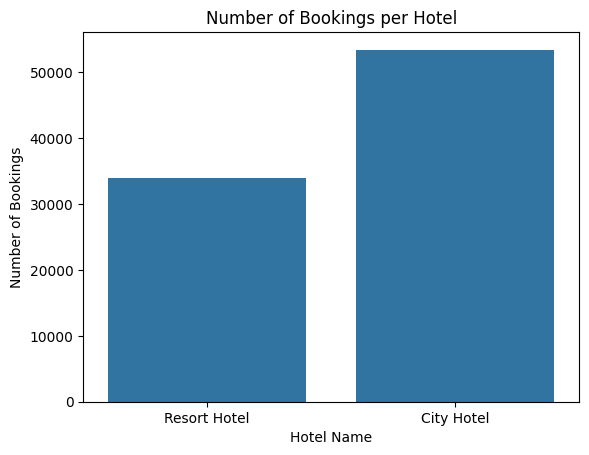

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=hotel_booking, x="hotel")
plt.title("Number of Bookings per Hotel")
plt.xlabel("Hotel Name")
plt.ylabel("Number of Bookings")
plt.show()

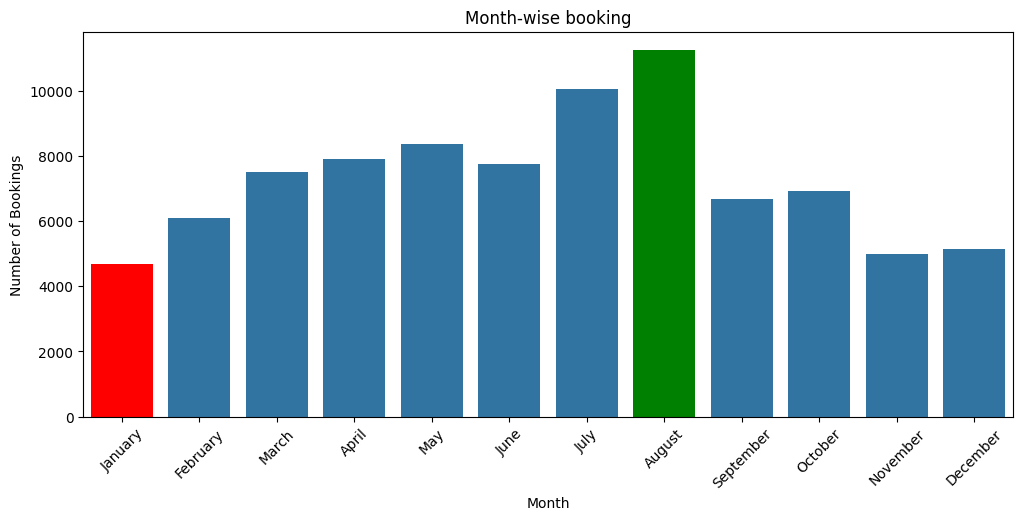

In [31]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=hotel_booking, x='arrival_date_month', order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

counts=hotel_booking['arrival_date_month'].value_counts().reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

ax.patches[counts.argmax()].set_facecolor('green')
ax.patches[counts.argmin()].set_facecolor('red')

plt.title("Month-wise booking")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

In [32]:
import plotly.express as px

In [33]:
country_counts = hotel_booking["country"].value_counts().reset_index() #.value_counts() gives a series, so for making it into a DataFrame we use .reset_index()
country_counts.columns = ["country", "bookings"] #Instead of generic names for columns, we name them as "country" and "bookings"

fig = px.choropleth(
    country_counts, #Use this dataframe
    locations = "country", #identifies the locations as per the country column values
    locationmode="ISO-3", #ISO-3 followed by dataset
    color = "bookings", #Color each country according to the value in the bookings column.
    hover_name = "country", #When the country is being hovered, it would show values of booking and country columns
    color_continuous_scale= "Viridis"
)

fig.show()

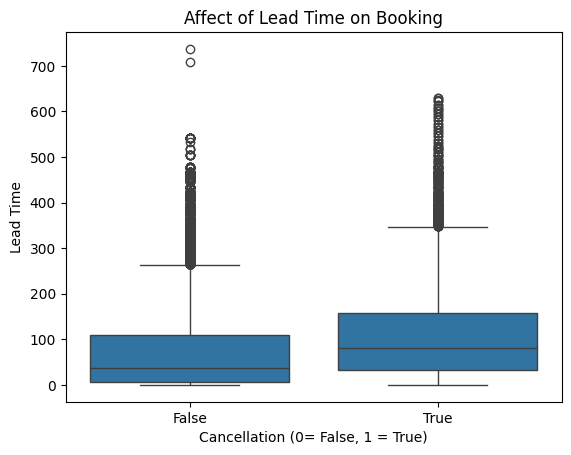

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(
    data = hotel_booking,
    x = "is_canceled",
    y = "lead_time"
)

plt.xlabel("Cancellation (0= False, 1 = True)")
plt.ylabel("Lead Time")
plt.title("Affect of Lead Time on Booking")
plt.show()

# Observation:
# - The median lead time for cancelled bookings is higher.
# - The distribution of cancelled bookings is shifted towards larger lead times.
# - This suggests that bookings made further in advance are more likely to be cancelled.

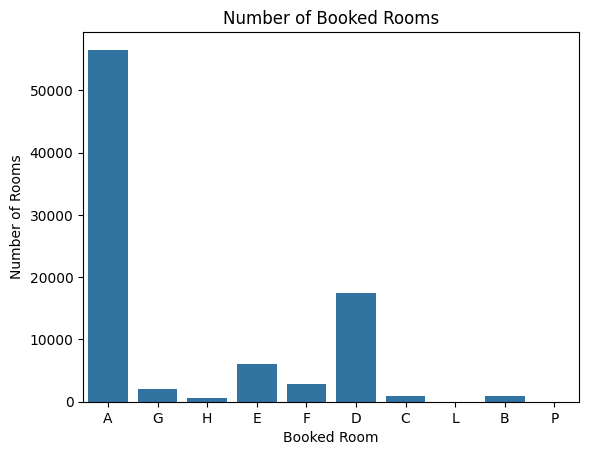

In [35]:
sns.countplot(
    data = hotel_booking,
    x = 'reserved_room_type'
)

plt.xlabel("Booked Room")
plt.ylabel("Number of Rooms")
plt.title("Number of Booked Rooms")
plt.show()

In [36]:
hotel_booking[['reserved_room_type', 'assigned_room_type']].head(60)

,reserved_room_type,assigned_room_type
18,A,G
58,G,G
57,A,D
56,H,H
118981,A,A
84147,A,A
78620,A,B
78618,A,A
109310,A,A
14359,E,E


In [37]:
import plotly.express as px

meal_counts = hotel_booking["meal"].value_counts().reset_index()
meal_counts.columns = ["meal", "count"]

fig = px.pie(
    meal_counts,
    names="meal",
    values="count",
    title="Most Popular Meal Plan",
    hole=0.5
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

# Observation:
# BB (Bed & Breakfast) is the most preferred meal plan among hotel bookings,accounting for the largest proportion of reservations. Other meal plans such as HB, SC, and FB are chosen by comparatively fewer guests.

In [38]:
hotel_booking[['is_canceled']]

,is_canceled
18,False
58,False
57,False
56,False
118981,False
...,...
60224,True
65237,True
65235,True
4182,False


In [39]:
import plotly.express as px

cancel_counts = hotel_booking["is_canceled"].value_counts().reset_index()
cancel_counts.columns = ["is_canceled", "count"]

cancel_counts["is_canceled"] = cancel_counts["is_canceled"].map({
    False: "Not Cancelled",
    True: "Cancelled"
})

fig = px.pie(
    cancel_counts,
    names="is_canceled",
    values="count",
    title="Percentage of Cancelled Bookings",
    hole = 0.4
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

In [40]:
cancel_percent = hotel_booking["is_canceled"].mean() * 100

print(f"Cancelled Bookings: {cancel_percent:.2f}%")

Cancelled Bookings: 27.49%


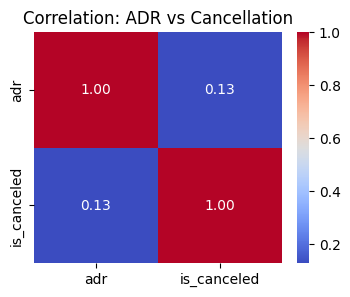

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = hotel_booking[["adr", "is_canceled"]].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation: ADR vs Cancellation")
plt.show()

In [42]:
pd.crosstab(
    hotel_booking["is_repeated_guest"],
    hotel_booking["is_canceled"],
    normalize="index"
) * 100



is_canceled,False,True
is_repeated_guest,,
False,71.704180,28.295820
True,92.357247,7.642753


In [43]:
#Analysis:
#• New Guests
#  - Cancelled: 28.30%
#  - Not Cancelled: 71.70%

#• Repeated Guests
#  - Cancelled: 7.64%
#  - Not Cancelled: 92.36%

#Inference:
#Repeated guests exhibit a substantially lower cancellation rate than first-time guests, suggesting that customer loyalty is associated with a higher likelihood of completing bookings.

<Axes: >

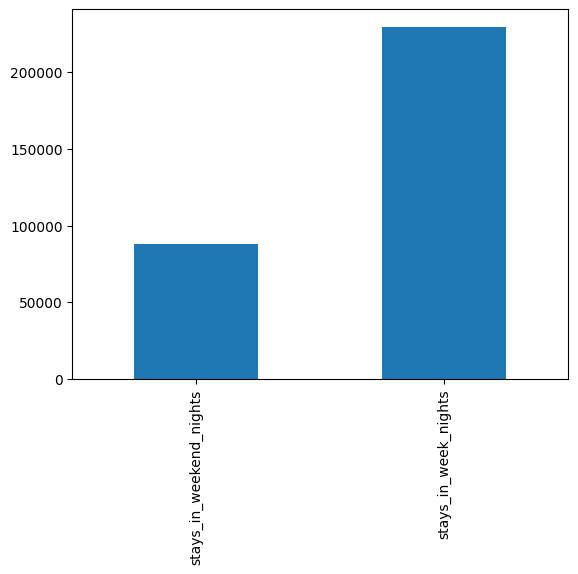

In [44]:
hotel_booking[["stays_in_weekend_nights", "stays_in_week_nights"]].sum().plot(kind="bar")

In [45]:
hotel_booking.to_csv("/kaggle/working/hotel_booking_cleaned.csv", index=False)